# Digital Image Processing — Spatial-Domain Analysis

**Author:** Yevhen Skyba

## Scope

1. Image loading and intensity-profile analysis
2. Point transformations
3. Histogram equalization
4. Local contextual enhancement
5. Salt-and-pepper noise reduction
6. Mean and Gaussian smoothing
7. Edge detection and image sharpening
8. Multi-stage image enhancement

This project explores fundamental spatial-domain image processing techniques using Python. The experiments investigate how pixel intensities, local neighborhoods, histograms, spatial filters, and enhancement methods affect grayscale images. Different parameters and processing approaches are compared to illustrate their practical effects on image brightness, contrast, noise, sharpness, and detail preservation.

All images are converted to grayscale and normalized to the `[0, 1]` range, where `0` represents black and `1` represents white.

Used libraries: `numpy`, `matplotlib`, `Pillow`, `scipy`, `scikit-image`.


This section demonstrates the corresponding image-processing technique and compares its effect across different parameters or inputs.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from scipy import ndimage
from skimage import exposure

%matplotlib inline
plt.rcParams["image.cmap"] = "gray"
plt.rcParams["figure.figsize"] = (6, 4)

DATA_DIR = "./dataset"
OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

_figure_counter = 0

def save_figure(prefix="figure"):
    global _figure_counter
    _figure_counter += 1
    path = os.path.join(OUTPUT_DIR, f"{_figure_counter:02d}_{prefix}.png")
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved figure: {path}")
    plt.show()
    plt.close()


## Dataset Layout

```text
image-processing/
├── dataset/
│   ├── chest-xray.tif
│   ├── spectrum.tif
│   └── ...
├── outputs/
└── image_processing.ipynb
```

Generated figures and processed images are written to `outputs/`.

The supplied datasets are not included in this portfolio repository; add only datasets that you are legally allowed to redistribute.

## Helper Functions

The helper functions provide a common interface for loading grayscale images, saving processed images, exporting figures, displaying individual images, comparing multiple results, and plotting intensity histograms. Centralizing these operations keeps the individual experiments concise and ensures that all images are processed and exported consistently.

In [2]:
DATA_DIR = "./dataset"
OUTPUT_DIR = "./outputs"

def load_gray(name):
    img = Image.open(os.path.join(DATA_DIR, name)).convert("L")
    return np.array(img) / 255.0

def save_gray(img, name):
    path = os.path.join(OUTPUT_DIR, name)
    img_uint8 = np.uint8(np.clip(img, 0, 1) * 255)
    Image.fromarray(img_uint8).save(path)

def show_img(img, title="", prefix="image"):
    plt.figure(figsize=(6, 5))
    plt.imshow(img, vmin=0, vmax=1)
    plt.title(title)
    plt.axis("off")
    save_figure(prefix)

def show_many_imgs(images, titles, cols=3, prefix="comparison"):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=(5 * cols, 4 * rows))
    for i in range(len(images)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i], vmin=0, vmax=1)
        plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    save_figure(prefix)

def plot_histogram(img, title, prefix="histogram"):
    plt.figure(figsize=(6, 4))
    plt.hist(img.ravel(), bins=256, range=(0, 1))
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Pixel count")
    save_figure(prefix)


---

The workflow begins by loading grayscale images, inspecting their dimensions and intensity range, and analyzing horizontal and vertical intensity profiles.

An image can be represented as a two-dimensional matrix `I(y, x)`, where `y` denotes the row and `x` denotes the column. An intensity profile shows how pixel values change along a selected horizontal or vertical line. Such profiles can reveal transitions between bright and dark regions, including potential edges and other local variations.

A rectangular region of interest (ROI) is also extracted and exported separately for further processing.


Image shape: (494, 600)
Minimum intensity: 0.0
Maximum intensity: 0.22745098039215686
Saved figure: ./outputs\01_image.png


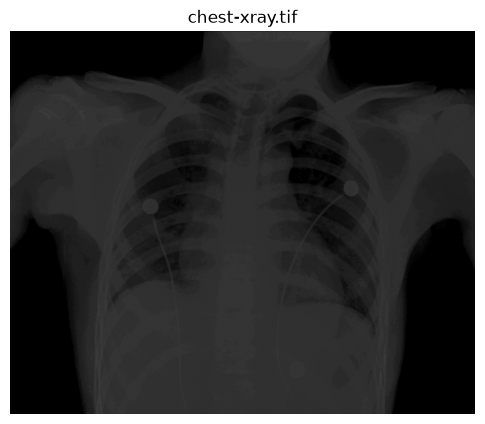

In [3]:
img = load_gray("chest-xray.tif")

print("Image shape:", img.shape)
print("Minimum intensity:", img.min())
print("Maximum intensity:", img.max())

show_img(img, "chest-xray.tif")

Saved figure: ./outputs\02_figure.png


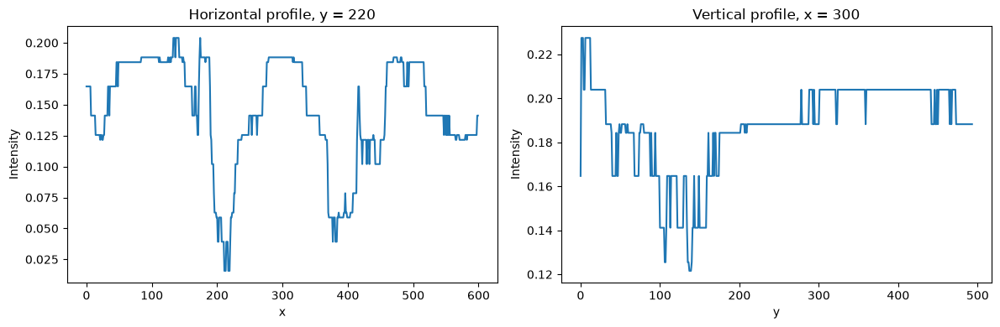

Saved figure: ./outputs\03_figure.png


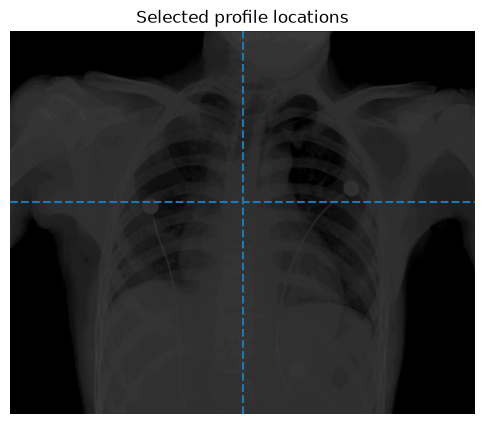

In [4]:
y = 220
x = 300

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(img[y, :])
plt.title("Horizontal profile, y = " + str(y))
plt.xlabel("x")
plt.ylabel("Intensity")

plt.subplot(1, 2, 2)
plt.plot(img[:, x])
plt.title("Vertical profile, x = " + str(x))
plt.xlabel("y")
plt.ylabel("Intensity")

plt.tight_layout()
save_figure()

plt.figure(figsize=(6, 5))
plt.imshow(img, vmin=0, vmax=1)
plt.axhline(y, linestyle="--")
plt.axvline(x, linestyle="--")
plt.title("Selected profile locations")
plt.axis("off")
save_figure()

Saved figure: ./outputs\04_image.png


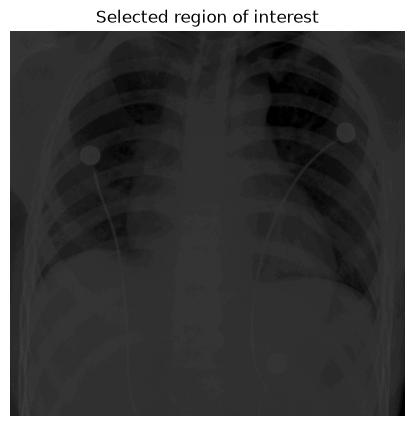

In [ ]:
y1, y2 = 100, 490
x1, x2 = 100, 500

roi = img[y1:y2, x1:x2]

show_img(roi, "Selected region of interest")
save_gray(roi, "chest_xray_roi.png")

---

Point transformations operate independently on each pixel of an image. This means that the new pixel value depends only on its original intensity and not on the values of neighboring pixels.

The general form of a point transformation is:

$$s = T(r)$$

where `r` is the input pixel intensity and `s` is the output pixel intensity. These operations are primarily used to adjust image brightness, contrast, and grayscale dynamic range.

### 2.1 Multiplication by a Constant

The transformation under investigation is:

$$T(r) = c \cdot r$$

The parameter `c` controls the brightness scaling factor. For `c < 1`, the image is darkened, while for `c > 1`, the image is brightened. After the transformation, pixel values are clipped to the range `[0, 1]`, since intensities cannot be darker than black or brighter than white.


Saved figure: ./outputs\05_comparison.png


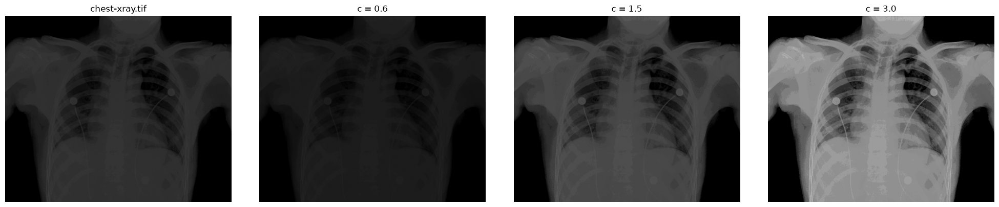

Saved figure: ./outputs\06_comparison.png


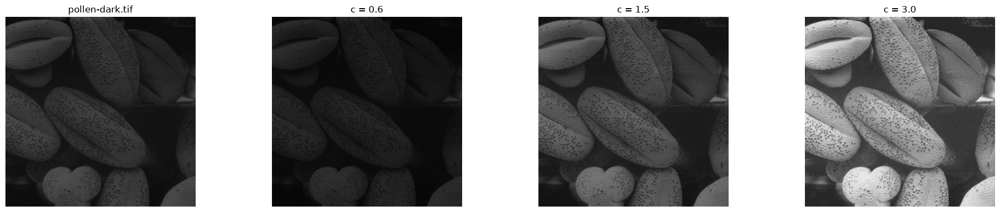

Saved figure: ./outputs\07_comparison.png


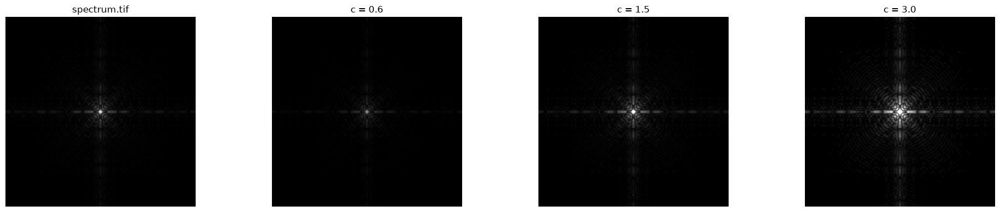

Saved figure: ./outputs\08_figure.png


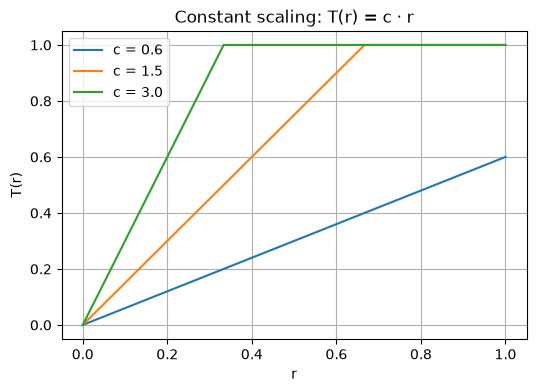

In [6]:
r = np.linspace(0, 1, 256)
constants = [0.6, 1.5, 3.0]

for name in ["chest-xray.tif", "pollen-dark.tif", "spectrum.tif"]:
    img = load_gray(name)
    results = [img]
    titles = [name]

    for c in constants:
        results.append(np.clip(c * img, 0, 1))
        titles.append("c = " + str(c))

    show_many_imgs(results, titles, cols=4)

for c in constants:
    plt.plot(r, np.clip(c * r, 0, 1), label="c = " + str(c))

plt.title("Constant scaling: T(r) = c · r")
plt.xlabel("r")
plt.ylabel("T(r)")
plt.grid(True)
plt.legend()
save_figure()


Multiplication by a constant changes the brightness of all pixels proportionally. Values of `c < 1` produce a darker image, while values of `c > 1` increase brightness. When the transformed intensity exceeds `1`, it is clipped to the maximum value, which can cause loss of detail in bright regions.

### 2.2 Logarithmic Transformation

The transformation under investigation is:

$$T(r) = c \cdot \log(1 + r)$$

The logarithmic transformation is nonlinear. It expands low-intensity values more strongly, making it useful for images where important details are hidden in dark regions.

Saved figure: ./outputs\09_comparison.png


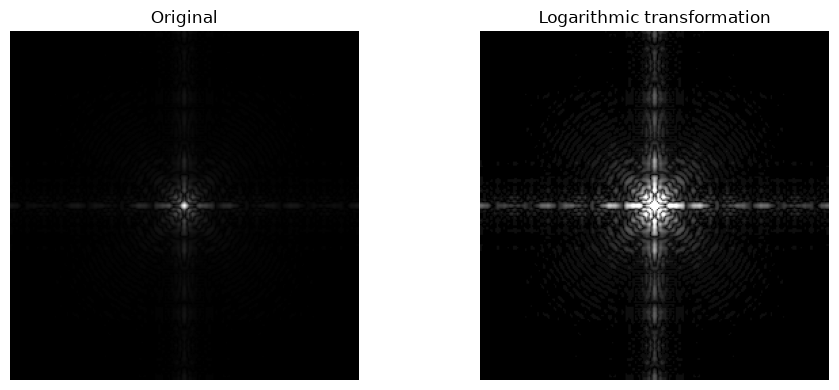

Saved figure: ./outputs\10_figure.png


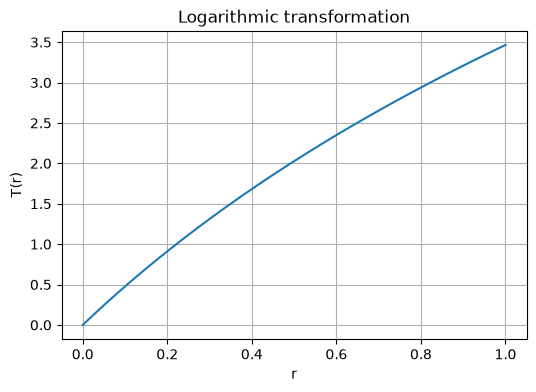

In [7]:
img = load_gray("spectrum.tif")
c = 5
log_img = c * np.log(1 + img)

show_many_imgs([img, log_img], ["Original", "Logarithmic transformation"], cols=2)

r = np.linspace(0, 1, 256)
plt.plot(r, c * np.log(1 + r))
plt.title("Logarithmic transformation")
plt.xlabel("r")
plt.ylabel("T(r)")
plt.grid(True)
save_figure()

The logarithmic transformation increases the visibility of darker intensity levels while compressing higher intensities. Unlike linear scaling, it affects different intensity ranges by different amounts, making it particularly useful for revealing details hidden in dark regions.

### 2.3 Dynamic-Range / Contrast Transformation

The transformation under investigation is:

$$T(r) = \frac{1}{1 + (m/r)^e}$$

where `r` represents the input pixel intensity and `T(r)` is the resulting intensity after the transformation. The parameter `m` defines the midpoint of the transformation, i.e. the intensity value around which the contrast changes most strongly. The parameter `e` controls the steepness of the transition between dark and bright intensity values.

Saved figure: ./outputs\11_comparison.png


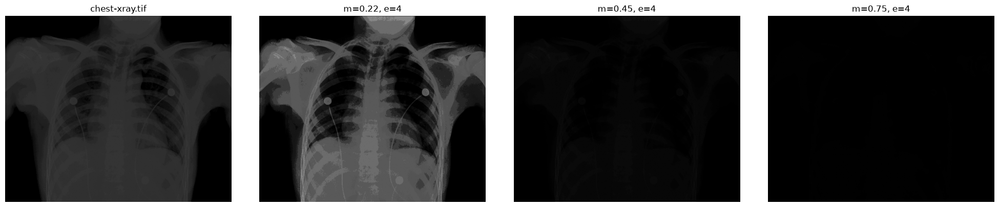

Saved figure: ./outputs\12_comparison.png


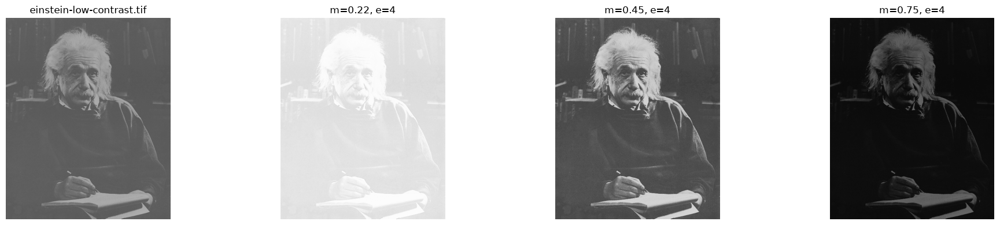

Saved figure: ./outputs\13_comparison.png


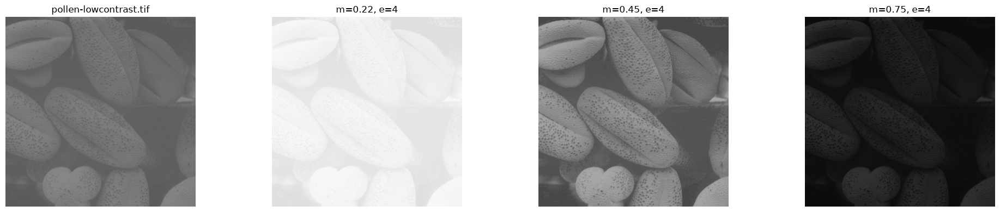

Saved figure: ./outputs\14_comparison.png


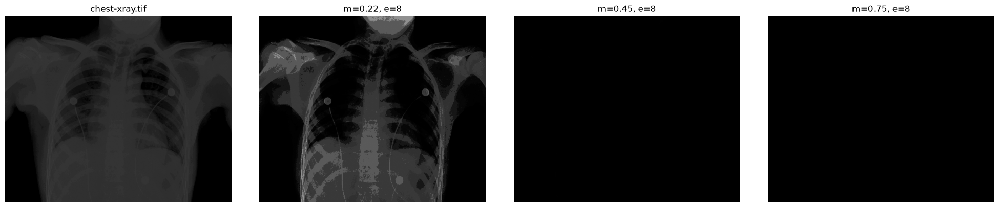

Saved figure: ./outputs\15_comparison.png


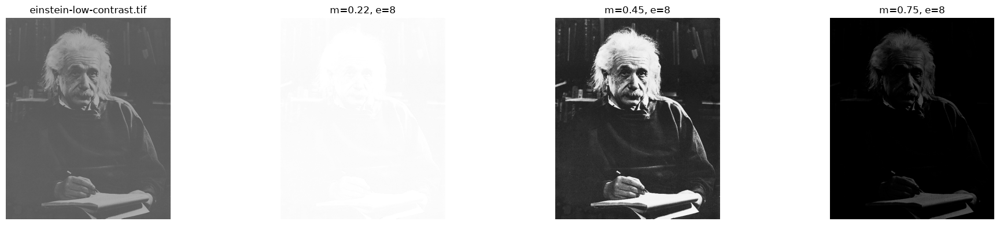

Saved figure: ./outputs\16_comparison.png


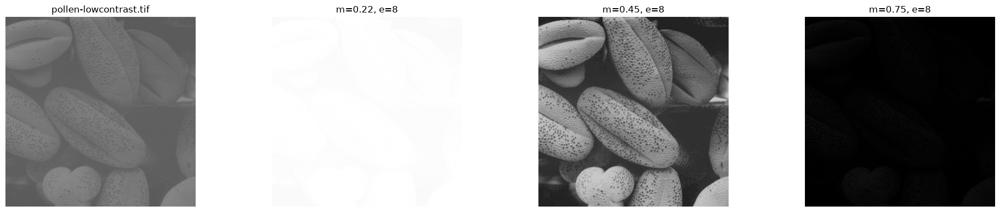

Saved figure: ./outputs\17_comparison.png


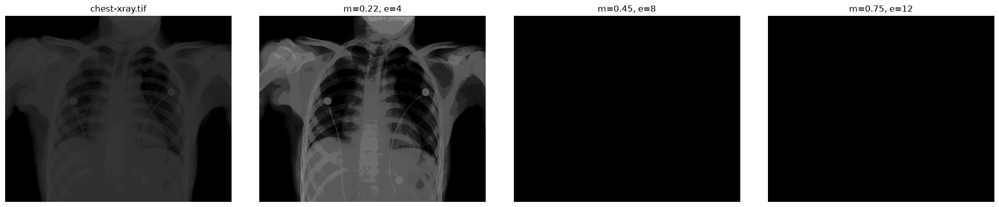

Saved figure: ./outputs\18_comparison.png


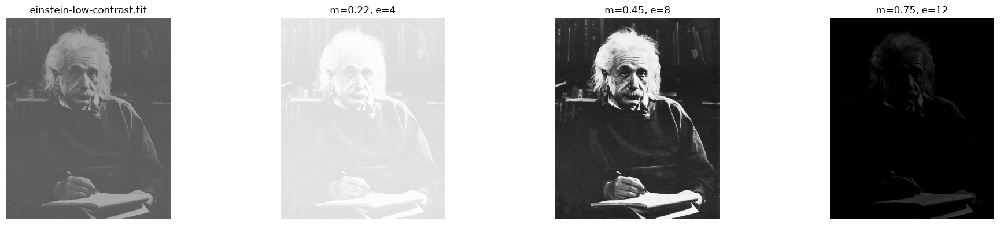

Saved figure: ./outputs\19_comparison.png


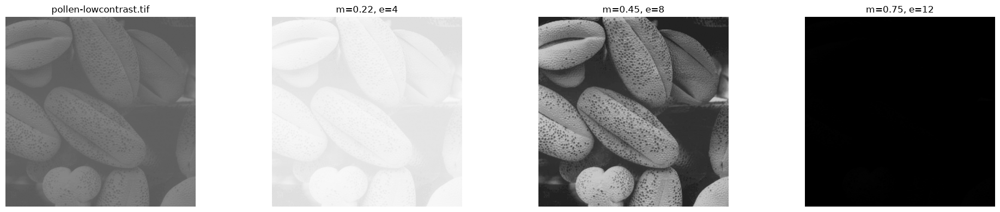

Saved figure: ./outputs\20_figure.png


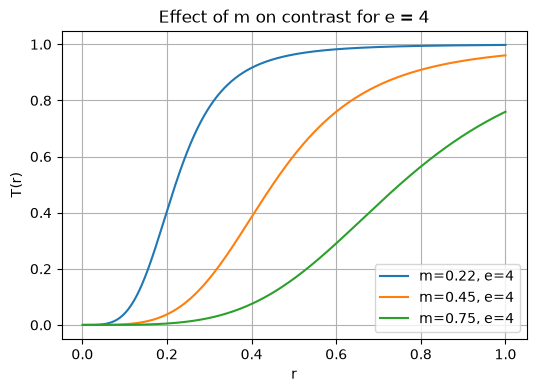

Saved figure: ./outputs\21_figure.png


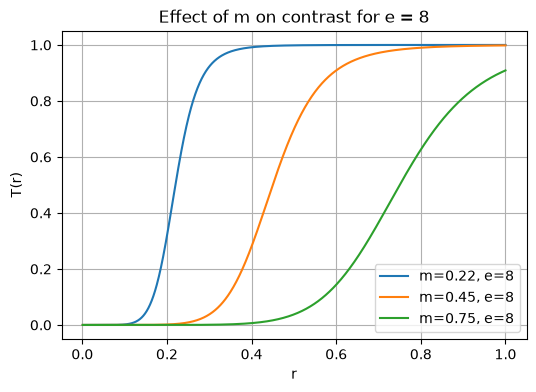

Saved figure: ./outputs\22_figure.png


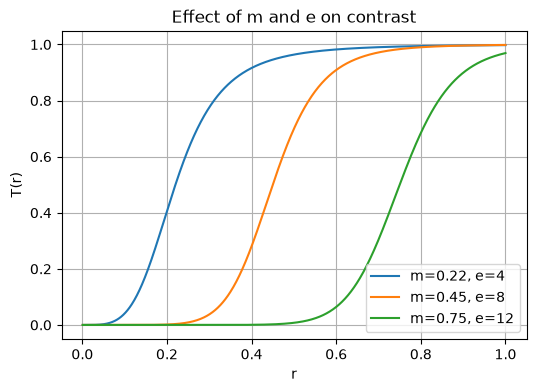

Saved figure: ./outputs\23_figure.png


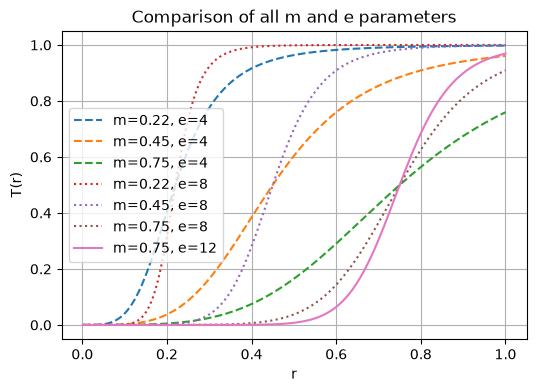

In [8]:
def contrast_transform(img, m, e):
    r = np.maximum(img, 0.000001)
    return 1 / (1 + (m / r) ** e)

r = np.linspace(0.001, 1, 1000)
params = [(0.22, 4), (0.45, 8), (0.75, 12)]
params_e4 = [(0.22, 4), (0.45, 4), (0.75, 4)]
params_e8 = [(0.22, 8), (0.45, 8), (0.75, 8)]



for name in ["chest-xray.tif", "einstein-low-contrast.tif", "pollen-lowcontrast.tif"]:
    img = load_gray(name)
    results = [img]
    titles = [name]
    for m, e in params_e4:
        results.append(contrast_transform(img, m, e))
        titles.append("m=" + str(m) + ", e=" + str(e))

    show_many_imgs(results, titles, cols=4)

for name in ["chest-xray.tif", "einstein-low-contrast.tif", "pollen-lowcontrast.tif"]:
    img = load_gray(name)
    results = [img]
    titles = [name]
    for m, e in params_e8:
        results.append(contrast_transform(img, m, e))
        titles.append("m=" + str(m) + ", e=" + str(e))
    show_many_imgs(results, titles, cols=4)

for name in ["chest-xray.tif", "einstein-low-contrast.tif", "pollen-lowcontrast.tif"]:
    img = load_gray(name)
    results = [img]
    titles = [name]
    for m, e in params:
        results.append(contrast_transform(img, m, e))
        titles.append("m=" + str(m) + ", e=" + str(e))
    show_many_imgs(results, titles, cols=4)

for m, e in params_e4:
    plt.plot(r, contrast_transform(r, m, e), label="m=" + str(m) + ", e=" + str(e))
plt.title("Effect of m on contrast for e = 4")
plt.xlabel("r")
plt.ylabel("T(r)")
plt.grid(True)
plt.legend()
save_figure()

for m, e in params_e8:
    plt.plot(r, contrast_transform(r, m, e), label="m=" + str(m) + ", e=" + str(e))
plt.title("Effect of m on contrast for e = 8")
plt.xlabel("r")
plt.ylabel("T(r)")
plt.grid(True)
plt.legend()
save_figure()

for m, e in params:
    plt.plot(r, contrast_transform(r, m, e), label="m=" + str(m) + ", e=" + str(e))
plt.title("Effect of m and e on contrast")
plt.xlabel("r")
plt.ylabel("T(r)")
plt.grid(True)
plt.legend()
save_figure()


all_params = []
for p in params_e4 + params_e8 + params:
    if p not in all_params:
        all_params.append(p)

for m, e in all_params:
    plt.plot(
        r,
        contrast_transform(r, m, e),
        linestyle="--" if e == 4 else ":" if e == 8 else "-",
        label="m=" + str(m) + ", e=" + str(e)
    )

plt.title("Comparison of all m and e parameters")
plt.xlabel("r")
plt.ylabel("T(r)")
plt.grid(True)
plt.legend()
save_figure()

The nonlinear contrast transformation modifies the distribution of intensity values around a selected midpoint `m`. The parameter `m` determines the intensity range where the contrast changes most strongly, while `e` controls the steepness of the transition between darker and brighter values.

Increasing `e` produces a sharper transition and stronger contrast enhancement around `m`. However, excessively large values can produce unnatural transitions and reduce the smoothness of tonal variations.


### 2.4 Gamma Correction

The transformation under investigation is:

$$s = c \cdot r^\gamma$$

We set `c = 1`. Gamma correction is a nonlinear method for adjusting image brightness. For images normalized to the range `[0, 1]`, values of `gamma < 1` brighten the image, while values of `gamma > 1` darken the image.

Saved figure: ./outputs\24_comparison.png


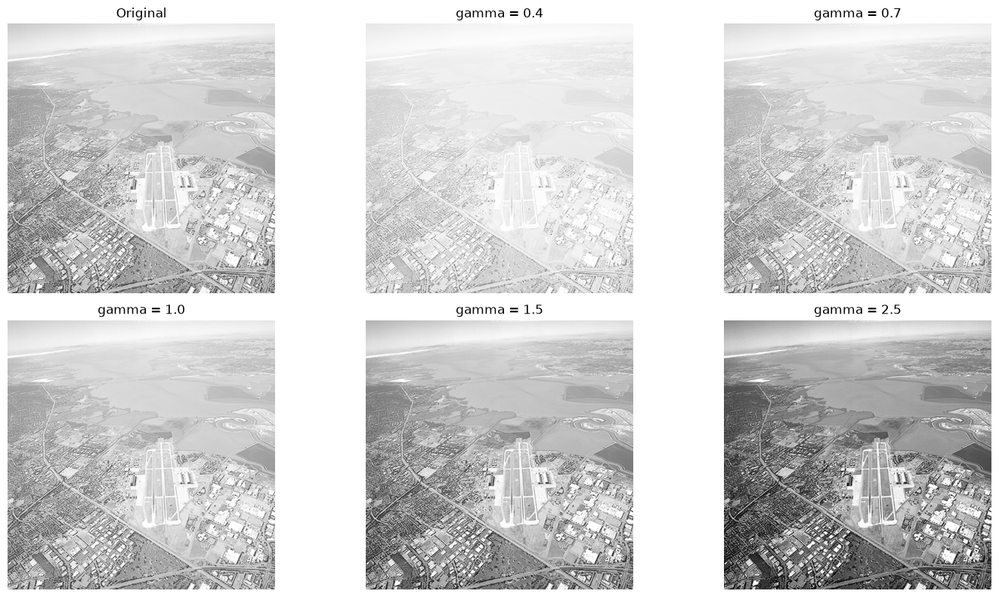

Saved figure: ./outputs\25_figure.png


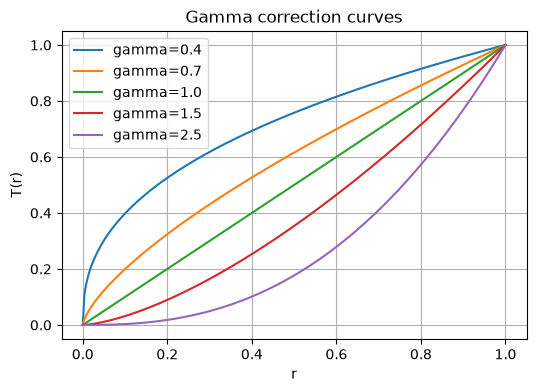

In [9]:
img = load_gray("aerial_view.tif")
gammas = [0.4, 0.7, 1.0, 1.5, 2.5]

results = [img]
titles = ["Original"]

for gamma in gammas:
    results.append(np.clip(img ** gamma, 0, 1))
    titles.append("gamma = " + str(gamma))

show_many_imgs(results, titles, cols=3)

r = np.linspace(0, 1, 256)
for gamma in gammas:
    plt.plot(r, r ** gamma, label="gamma=" + str(gamma))
plt.title("Gamma correction curves")
plt.xlabel("r")
plt.ylabel("T(r)")
plt.grid(True)
plt.legend()
save_figure()

Gamma correction provides a nonlinear way of modifying image brightness. Values of gamma < 1 brighten darker regions, while values of gamma > 1 darken the image. Because the transformation is applied globally, extreme gamma values can also cause loss of detail in parts of the intensity range.

---

Histogram equalization improves global contrast by remapping pixel intensities according to the cumulative distribution function (CDF) of the image histogram.

When intensity values are concentrated within a narrow range, the transformation spreads them across a wider portion of the available intensity range. This can make details more visible in images that are too dark, too bright, or have low global contrast. However, histogram equalization can also amplify noise or produce an overly strong contrast effect.


Saved figure: ./outputs\26_comparison.png


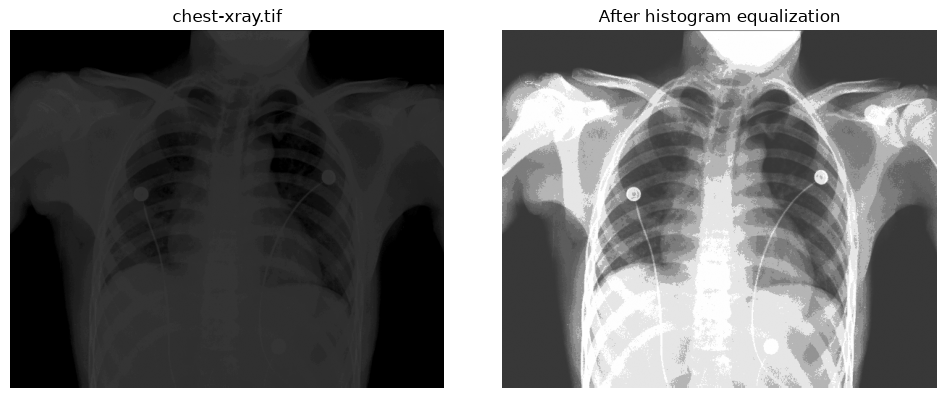

Saved figure: ./outputs\27_figure.png


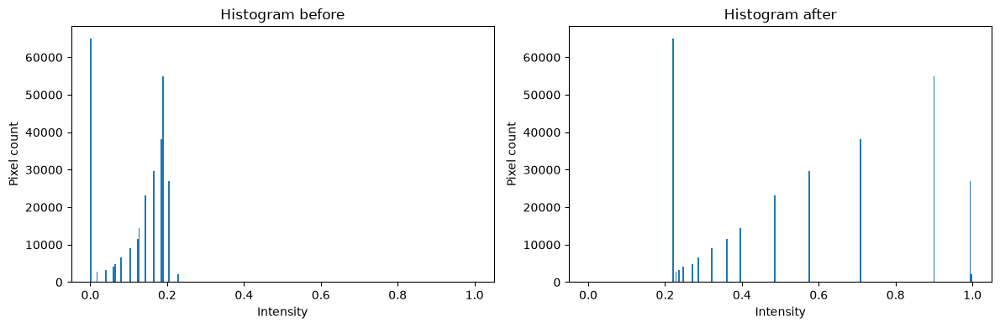

Saved figure: ./outputs\28_comparison.png


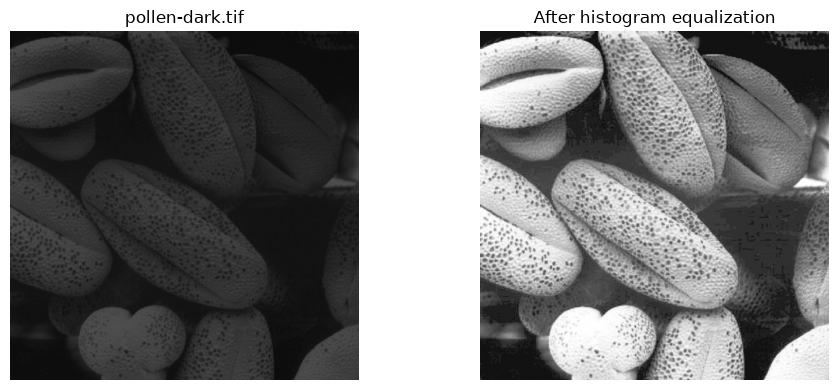

Saved figure: ./outputs\29_figure.png


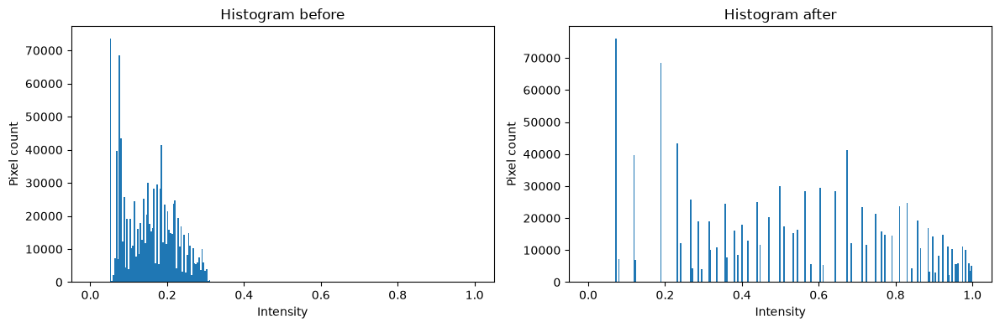

Saved figure: ./outputs\30_comparison.png


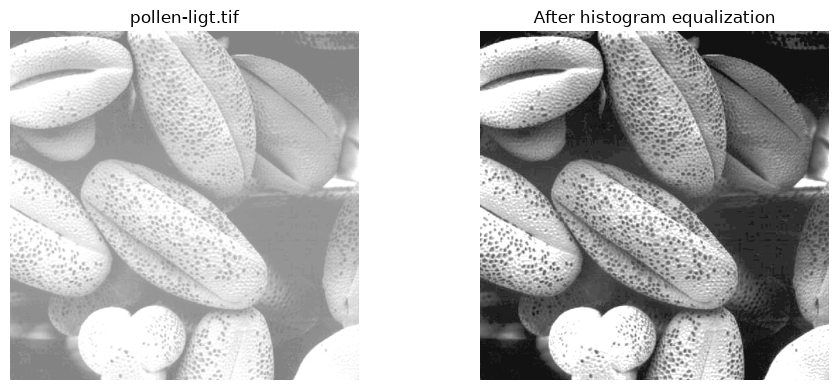

Saved figure: ./outputs\31_figure.png


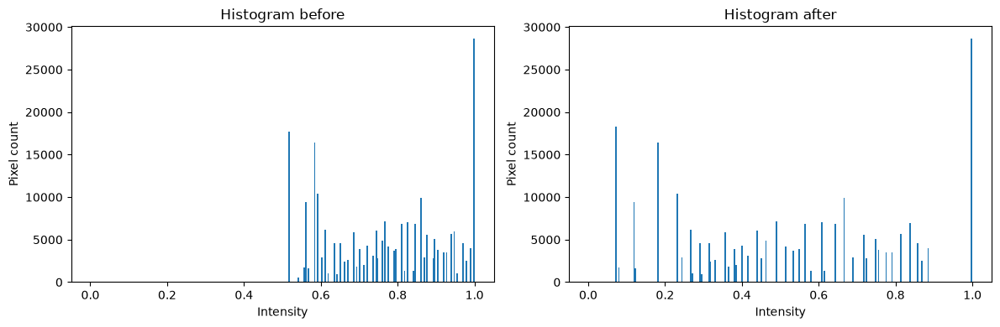

Saved figure: ./outputs\32_comparison.png


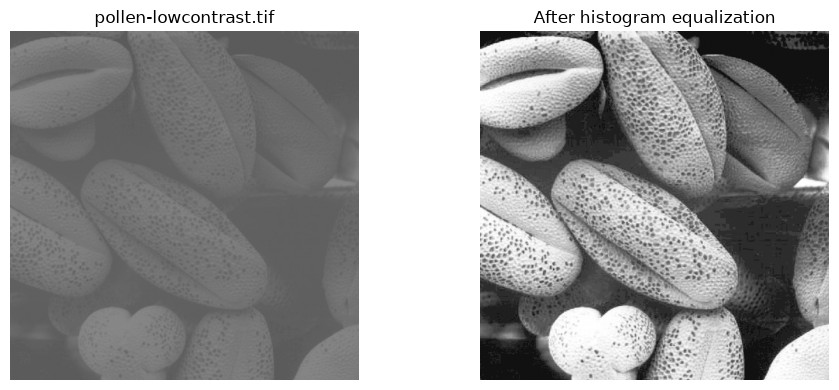

Saved figure: ./outputs\33_figure.png


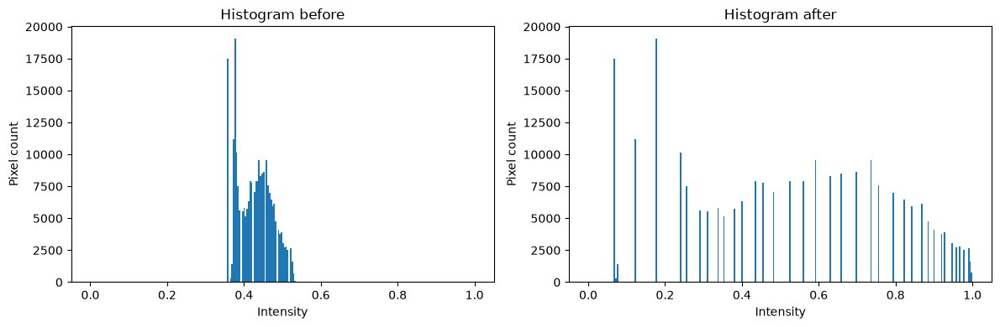

Saved figure: ./outputs\34_comparison.png


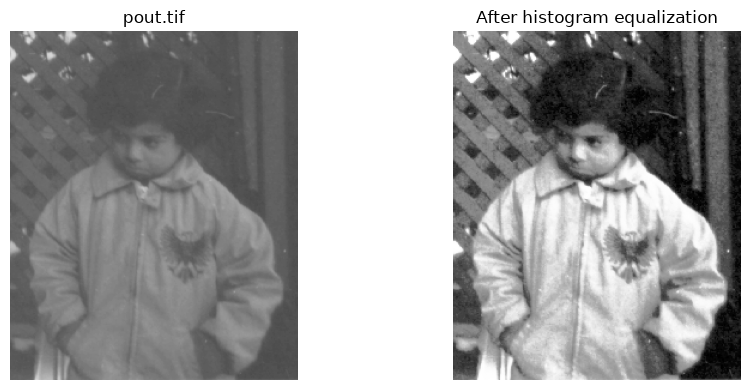

Saved figure: ./outputs\35_figure.png


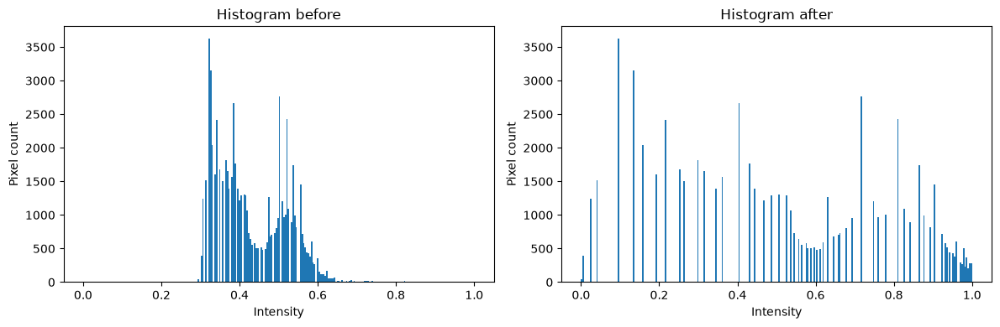

Saved figure: ./outputs\36_comparison.png


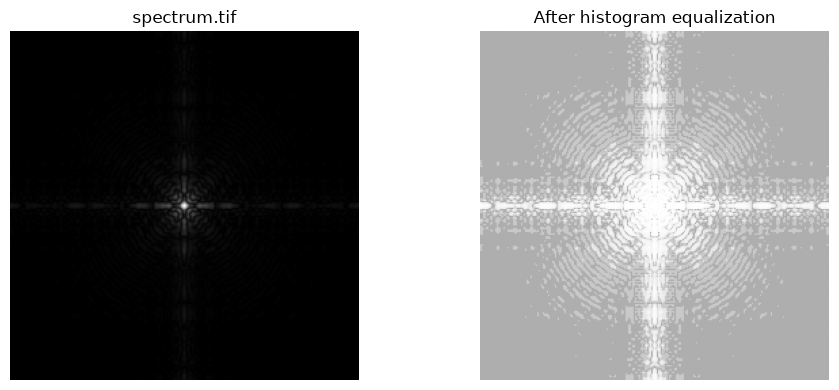

Saved figure: ./outputs\37_figure.png


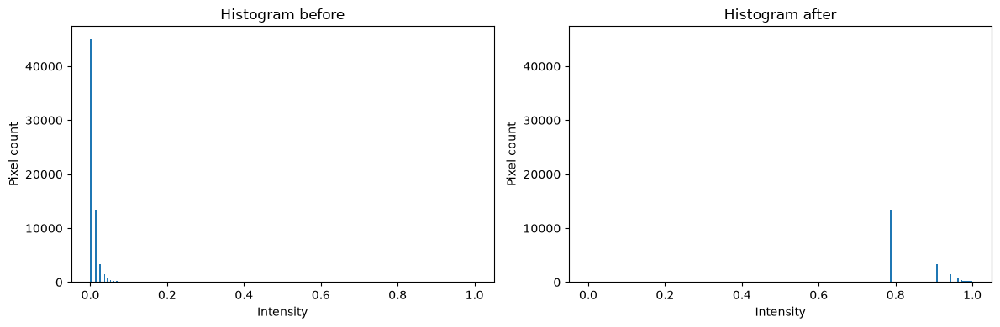

In [10]:
def histogram_equalization(name):
    img = load_gray(name)
    eq = exposure.equalize_hist(img)

    show_many_imgs([img, eq], [name, "After histogram equalization"], cols=2)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(img.ravel(), bins=256, range=(0, 1))
    plt.title("Histogram before")
    plt.xlabel("Intensity")
    plt.ylabel("Pixel count")

    plt.subplot(1, 2, 2)
    plt.hist(eq.ravel(), bins=256, range=(0, 1))
    plt.title("Histogram after")
    plt.xlabel("Intensity")
    plt.ylabel("Pixel count")

    plt.tight_layout()
    save_figure()

for name in ["chest-xray.tif", "pollen-dark.tif", "pollen-ligt.tif", "pollen-lowcontrast.tif", "pout.tif", "spectrum.tif"]:
    histogram_equalization(name)

---

Local contextual methods determine the output of a pixel using information from its surrounding neighborhood rather than from the entire image. This makes them useful when illumination or contrast varies spatially across an image.

The size of the neighborhood controls how local the enhancement is: smaller neighborhoods respond more strongly to fine details and local variations, while larger neighborhoods produce smoother and more stable results.


### 4.1 Local Histogram Equalization

Local histogram equalization enhances contrast independently within small regions of the image. The mask size determines the size of the neighborhood used in the calculations. A smaller mask provides more localized enhancement and can reveal fine details more strongly, but it may also amplify noise.

Saved figure: ./outputs\38_comparison.png


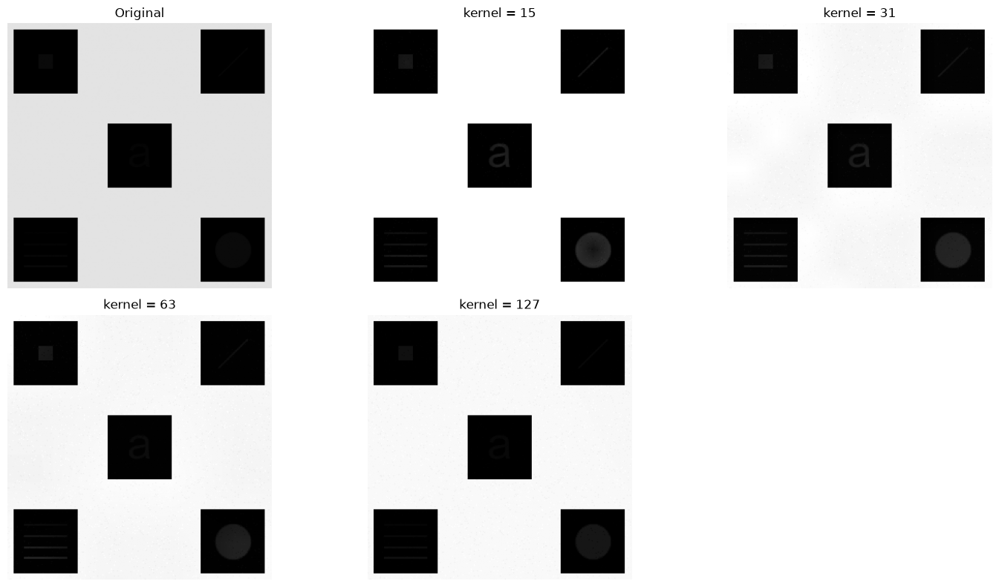

In [11]:
img = load_gray("hidden-symbols.tif")

results = [img]
titles = ["Original"]

for size in [15, 31, 63, 127]:
    result = exposure.equalize_adapthist(img, kernel_size=size, clip_limit=0.03)
    results.append(result)
    titles.append("kernel = " + str(size))

show_many_imgs(results, titles, cols=3)

Local histogram equalization enhances contrast independently in different regions of the image. Smaller kernels provide stronger local enhancement and can reveal fine details, but they may also amplify noise. Larger kernels produce a more gradual enhancement over larger regions.


### 4.2 Enhancement Using Local Statistics

This method uses the local mean and local standard deviation. The mean describes the background intensity within the pixel's neighborhood, while the standard deviation indicates how much the pixel intensities vary within that region.

The local standard deviation can be calculated as:

$$std = \sqrt{E[x^2] - E[x]^2}$$

The difference between the pixel intensity and its local mean is then amplified, increasing the local contrast.

Saved figure: ./outputs\39_comparison.png


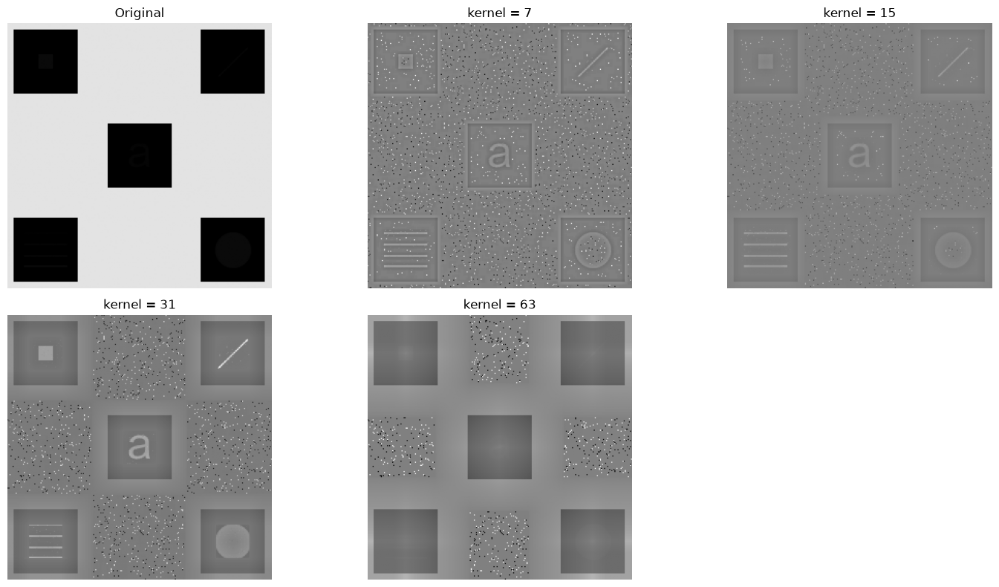

In [12]:
def local_stats(img, size, gain):
    mean = ndimage.uniform_filter(img, size=size)
    mean2 = ndimage.uniform_filter(img ** 2, size=size)
    std = np.sqrt(np.maximum(mean2 - mean ** 2, 0))
    result = np.mean(img) + gain * np.std(img) * (img - mean) / (std + 0.000001)
    return exposure.rescale_intensity(result, out_range=(0, 1))

results = [img]
titles = ["Original"]

for size in [7, 15, 31, 63]:
    results.append(local_stats(img, size, 1.6))
    titles.append("kernel = " + str(size))

show_many_imgs(results, titles, cols=3)

The local-statistics method enhances contrast using the mean and standard deviation calculated within a neighborhood around each pixel. This allows local intensity variations to be amplified even when the overall image has uneven illumination.

Smaller neighborhoods emphasize fine local details more strongly, but can also increase noise. Larger neighborhoods provide more stable results while potentially reducing the visibility of very small structures.


---

Salt-and-pepper noise is an impulse-noise model in which individual pixels are replaced by very bright or very dark values. Bright impulses are commonly referred to as "salt", while dark impulses are referred to as "pepper".

Mean, median, minimum, and maximum filters are compared using different neighborhood sizes. Each filter replaces a pixel according to a different statistic calculated from its local neighborhood.


Saved figure: ./outputs\40_comparison.png


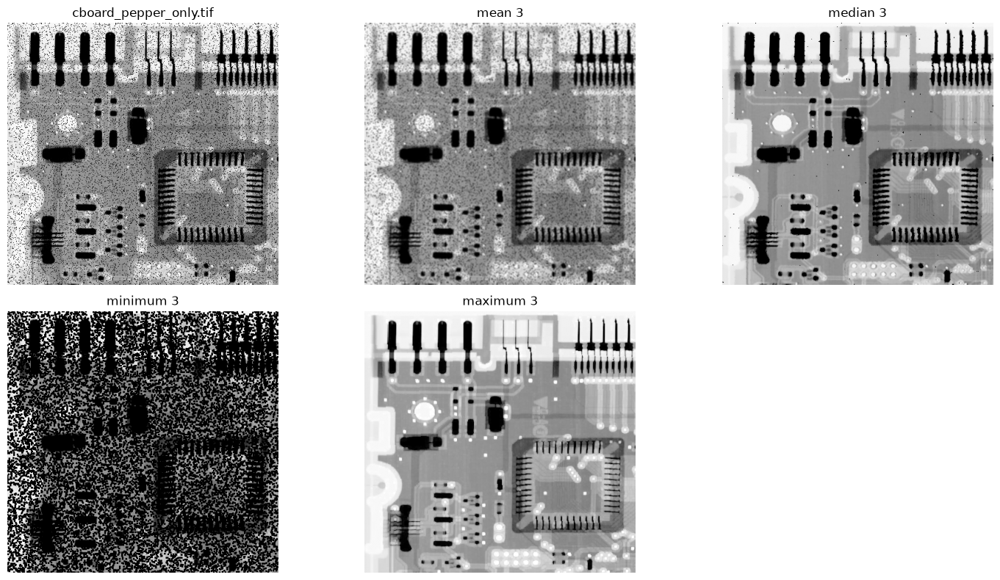

Saved figure: ./outputs\41_comparison.png


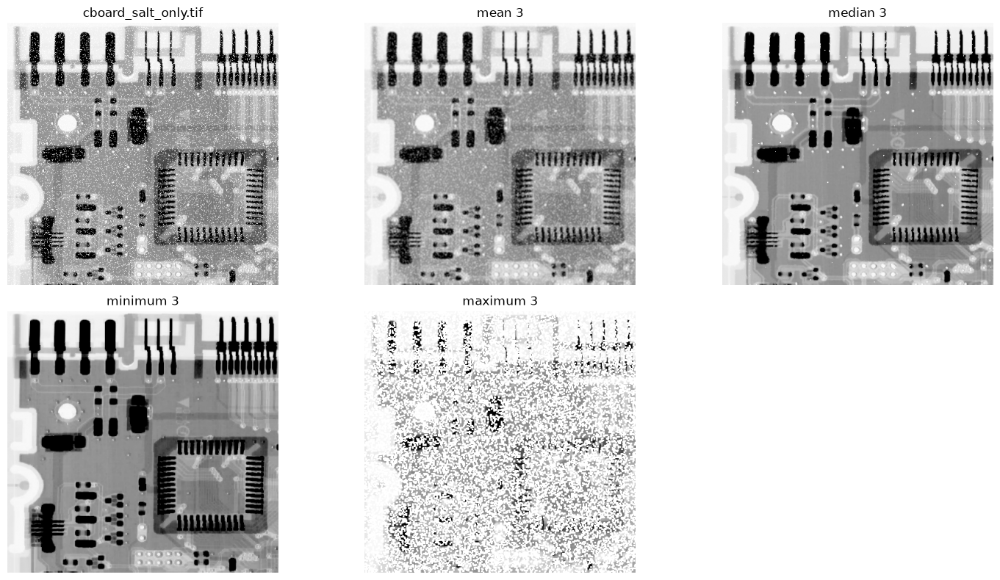

Saved figure: ./outputs\42_comparison.png


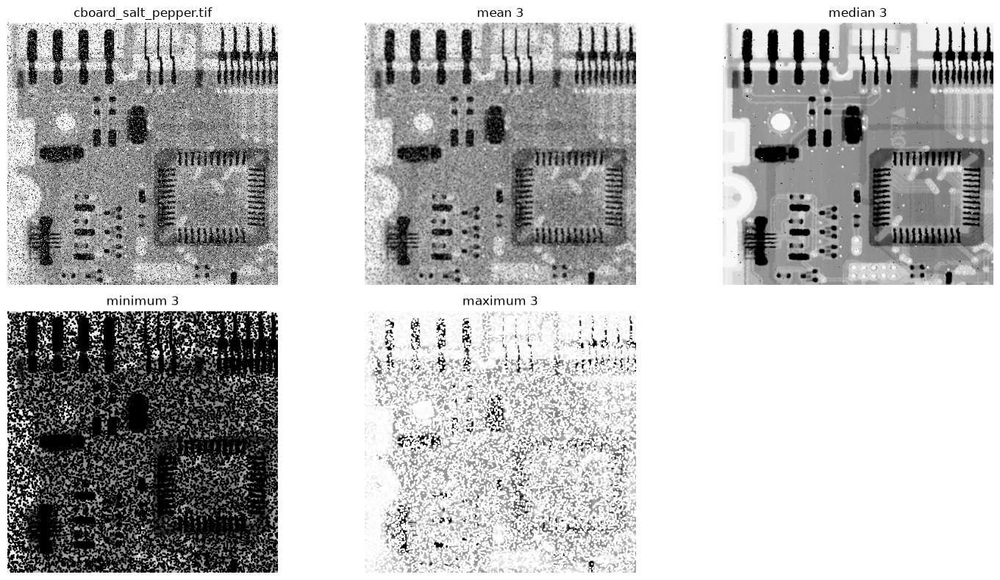

In [13]:
def compare_noise_filters(name, size):
    img = load_gray(name)
    avg = ndimage.uniform_filter(img, size=size)
    med = ndimage.median_filter(img, size=size)
    mn = ndimage.minimum_filter(img, size=size)
    mx = ndimage.maximum_filter(img, size=size)

    show_many_imgs(
        [img, avg, med, mn, mx],
        [name, "mean " + str(size), "median " + str(size), "minimum " + str(size), "maximum " + str(size)],
        cols=3
    )

for name in ["cboard_pepper_only.tif", "cboard_salt_only.tif", "cboard_salt_pepper.tif"]:
    compare_noise_filters(name, 3)

Saved figure: ./outputs\43_comparison.png


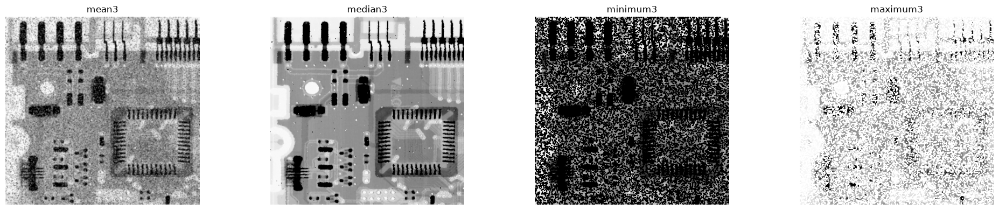

Saved figure: ./outputs\44_comparison.png


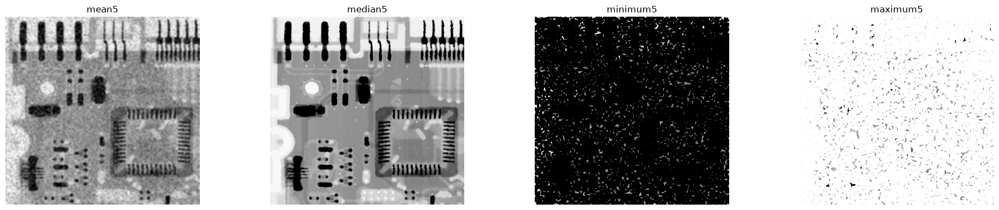

Saved figure: ./outputs\45_comparison.png


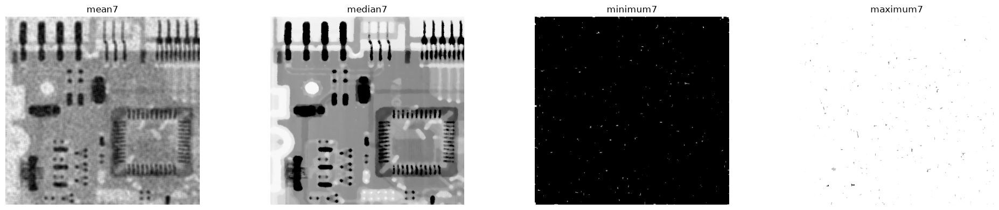

Saved figure: ./outputs\46_comparison.png


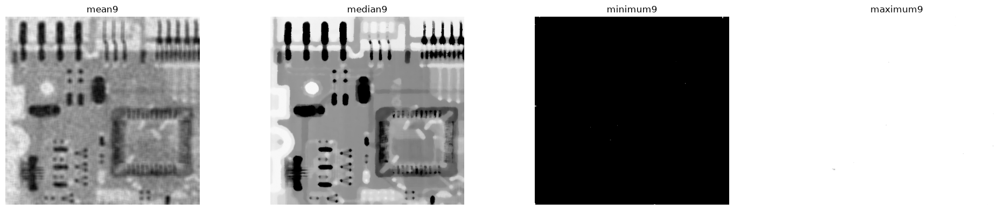

In [14]:
img = load_gray("cboard_salt_pepper.tif")

for size in [3, 5, 7, 9]:
    avg = ndimage.uniform_filter(img, size=size)
    med = ndimage.median_filter(img, size=size)
    mn = ndimage.minimum_filter(img, size=size)
    mx = ndimage.maximum_filter(img, size=size)
    show_many_imgs([avg, med, mn, mx], ["mean" +  str(size), "median" +  str(size), "minimum" +  str(size), "maximum" +  str(size)], cols=4)

The median filter provides the most effective general reduction of mixed salt-and-pepper noise because isolated extreme values have little influence on the median. In contrast, the mean filter reduces noise by averaging neighboring pixels but tends to blur edges.

The minimum filter is particularly effective against bright salt impulses but can darken the image, while the maximum filter is effective against dark pepper impulses but can expand bright regions.

---

Low-pass filters smooth the image and suppress rapid changes in intensity. In practice, this means reducing high spatial frequencies, such as noise, fine details, and sharp edges.

A mean filter assigns equal weights to all pixels within the mask. A Gaussian filter also smooths the image, but assigns greater weight to pixels closer to the center of the mask, which usually produces a more natural-looking result.

Saved figure: ./outputs\47_comparison.png


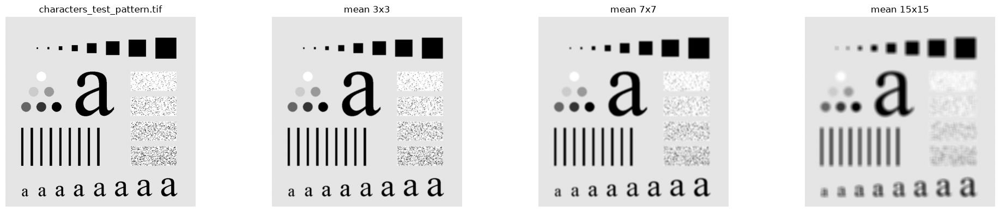

Saved figure: ./outputs\48_comparison.png


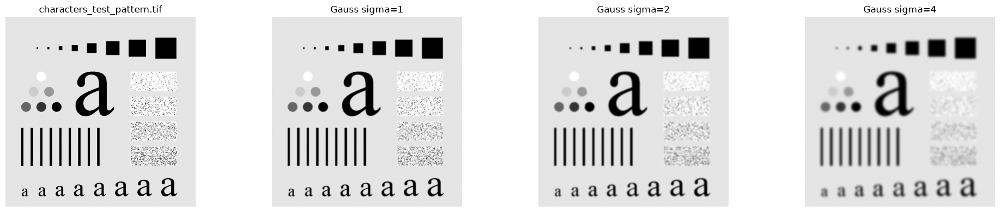

Saved figure: ./outputs\49_comparison.png


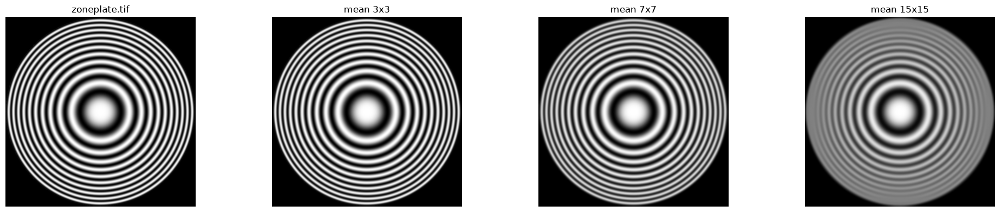

Saved figure: ./outputs\50_comparison.png


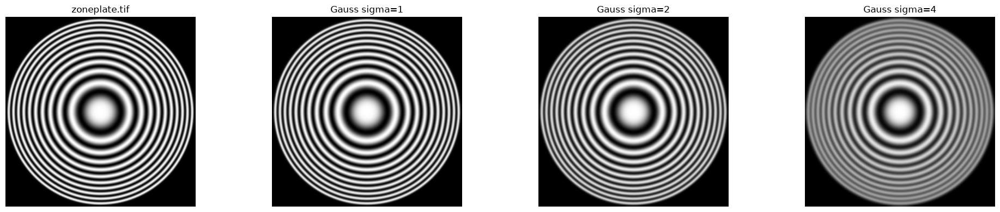

In [15]:
for name in ["characters_test_pattern.tif", "zoneplate.tif"]:
    img = load_gray(name)

    avg3 = ndimage.uniform_filter(img, size=3)
    avg7 = ndimage.uniform_filter(img, size=7)
    avg15 = ndimage.uniform_filter(img, size=15)

    show_many_imgs([img, avg3, avg7, avg15], [name, "mean 3x3", "mean 7x7", "mean 15x15"], cols=4)

    g1 = ndimage.gaussian_filter(img, sigma=1)
    g2 = ndimage.gaussian_filter(img, sigma=2)
    g4 = ndimage.gaussian_filter(img, sigma=4)

    show_many_imgs([img, g1, g2, g4], [name, "Gauss sigma=1", "Gauss sigma=2", "Gauss sigma=4"], cols=4)

A larger mask in the mean filter or a larger `sigma` value in the Gaussian filter produces stronger image blurring. The mean filter is simple, but it can easily blur edges because all pixels within the mask have the same influence on the result. The Gaussian filter usually produces more natural smoothing because pixels closer to the center of the mask have a greater influence than more distant pixels.

---

High-pass filters enhance rapid changes in intensity, such as edges and fine details. They are the opposite of low-pass filters: instead of smoothing the image, they emphasize differences between neighboring pixels.

This section examines the Sobel operator, the Laplacian, and sharpening methods including unsharp masking and high boost filtering.

### 7.1 Sobel Operator

The Sobel operator is used for edge detection by computing an approximation of the image gradient. The `Gx` kernel detects intensity changes along the `x`-axis, primarily highlighting vertical edges, while the `Gy` kernel detects changes along the `y`-axis, primarily highlighting horizontal edges.

After computing both components, the overall edge magnitude can be calculated as:

$$G = \sqrt{G_x^2 + G_y^2}$$

Saved figure: ./outputs\51_comparison.png


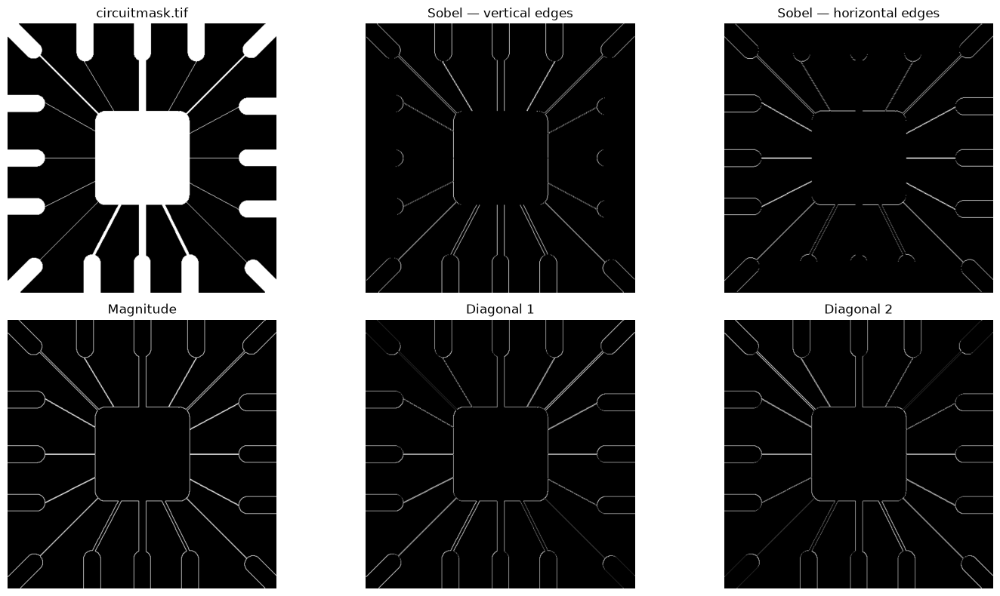

Saved figure: ./outputs\52_comparison.png


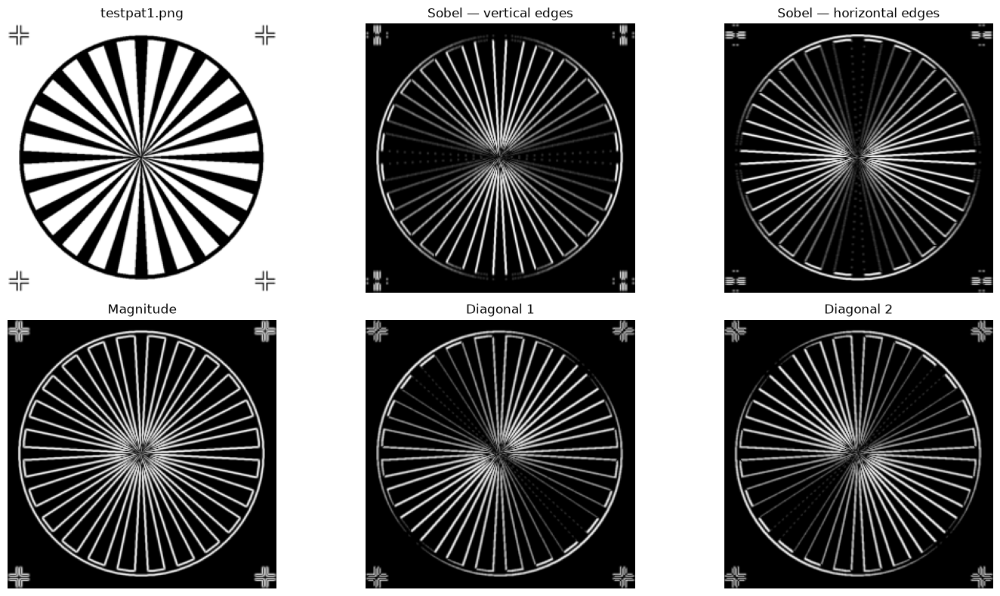

In [16]:
for name in ["circuitmask.tif", "testpat1.png"]:
    img = load_gray(name)

    gx = ndimage.sobel(img, axis=1)
    gy = ndimage.sobel(img, axis=0)
    mag = np.sqrt(gx ** 2 + gy ** 2)

    k1 = np.array([[2, 1, 0], [1, 0, -1], [0, -1, -2]])
    k2 = np.array([[0, 1, 2], [-1, 0, 1], [-2, -1, 0]])
    d1 = ndimage.convolve(img, k1)
    d2 = ndimage.convolve(img, k2)

    images = [
        img,
        exposure.rescale_intensity(np.abs(gx), out_range=(0, 1)),
        exposure.rescale_intensity(np.abs(gy), out_range=(0, 1)),
        exposure.rescale_intensity(mag, out_range=(0, 1)),
        exposure.rescale_intensity(np.abs(d1), out_range=(0, 1)),
        exposure.rescale_intensity(np.abs(d2), out_range=(0, 1)),
    ]
    titles = [name, "Sobel — vertical edges", "Sobel — horizontal edges", "Magnitude", "Diagonal 1", "Diagonal 2"]
    show_many_imgs(images, titles, cols=3)

### 7.2 Laplacian Sharpening

The Laplacian is a second-order derivative operator. It responds to rapid changes in intensity regardless of their direction, making it useful for emphasizing details and edges throughout the image.

For sharpening, the Laplacian result is either added to or subtracted from the original image, depending on the chosen kernel and the sign convention of the operator.

Saved figure: ./outputs\53_comparison.png


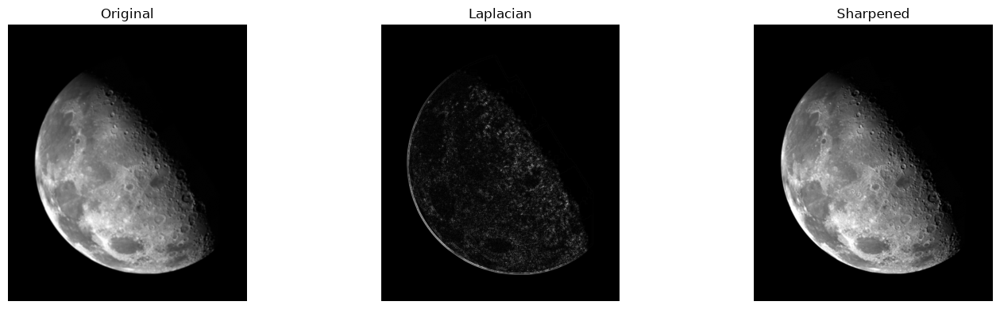

In [17]:
img = load_gray("blurry-moon.tif")

lap = ndimage.laplace(img)
sharp = np.clip(img - 0.7 * lap, 0, 1)

show_many_imgs(
    [img, exposure.rescale_intensity(np.abs(lap), out_range=(0, 1)), sharp],
    ["Original", "Laplacian", "Sharpened"],
    cols=3
)

### 7.3 Unsharp Masking and High Boost

Unsharp masking works by blurring the image, subtracting the blurred version from the original, and adding the resulting detail mask back to the input image. The mask mainly contains high-frequency information, such as edges and fine details.

High boost filtering follows a similar approach but applies a stronger amplification of the detail mask. This produces more pronounced sharpening, but excessive amplification can introduce unnatural effects and artifacts.

Saved figure: ./outputs\54_comparison.png


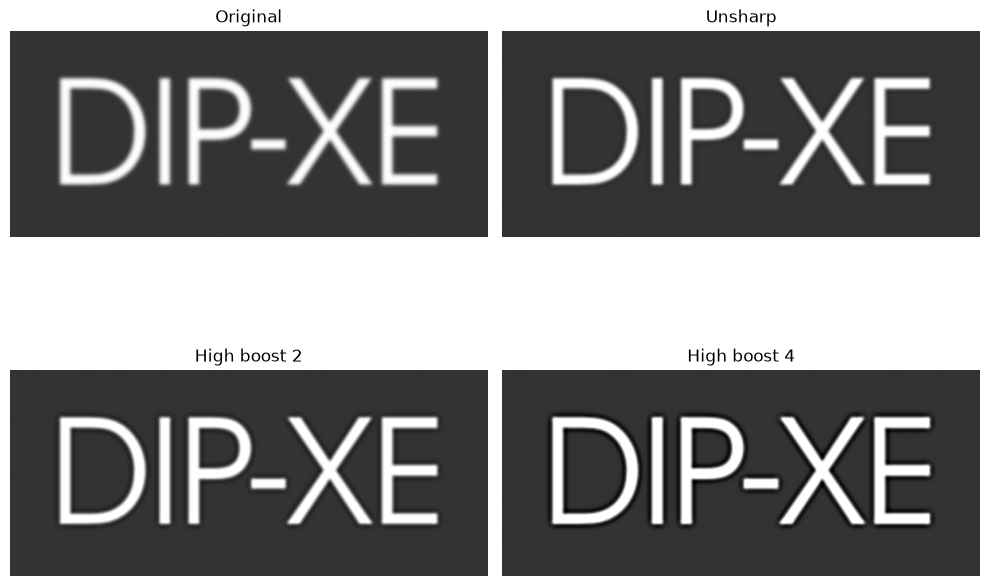

In [18]:
img = load_gray("text-dipxe-blurred.tif")
blur = ndimage.gaussian_filter(img, sigma=2)
mask = img - blur

unsharp = np.clip(img + 1.0 * mask, 0, 1)
high_boost_2 = np.clip(img + 2.0 * mask, 0, 1)
high_boost_4 = np.clip(img + 4.0 * mask, 0, 1)

show_many_imgs(
    [img, unsharp, high_boost_2, high_boost_4],
    ["Original", "Unsharp", "High boost 2", "High boost 4"],
    cols=2
)

The Sobel operator detects edges by analyzing intensity changes in specific directions, allowing vertical, horizontal, and diagonal edges to be examined separately. The Laplacian responds to rapid intensity changes regardless of direction, making it useful for emphasizing fine details and sharpening.

Unsharp masking and high boost improve image sharpness by adding high-frequency information back to the image. However, excessive enhancement can introduce artifacts, amplify noise, and produce an unnatural appearance.

---

Multi-stage processing combines several image-processing methods into a single sequence. In this section, the `bonescan.tif` image is enhanced through a series of operations: gamma correction, local histogram equalization, median filtering, high boost sharpening, and contrast stretching.

Each stage addresses a different aspect of the image. Gamma correction adjusts brightness, local histogram equalization improves contrast, the median filter reduces noise, high boost enhances fine details, and the final contrast stretching adjusts the overall intensity range.

Saved figure: ./outputs\55_comparison.png


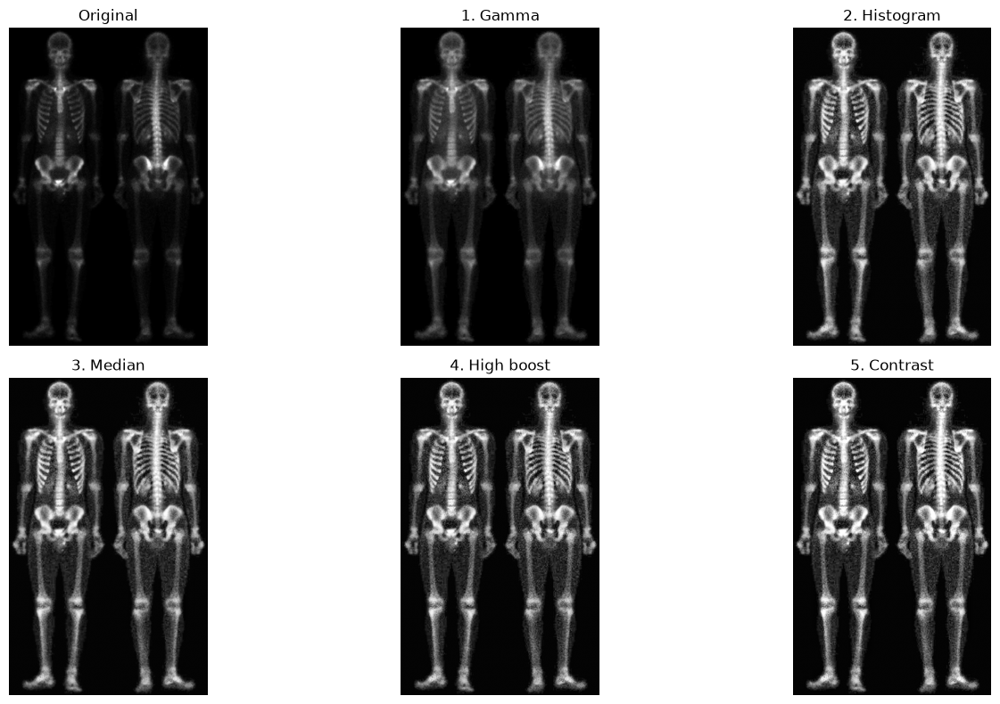

In [19]:
img = load_gray("bonescan.tif")

stage1 = img ** 0.7
stage2 = exposure.equalize_adapthist(stage1, kernel_size=64, clip_limit=0.02)
stage3 = ndimage.median_filter(stage2, size=3)

blur = ndimage.gaussian_filter(stage3, sigma=1.2)
stage4 = np.clip(stage3 + 1.5 * (stage3 - blur), 0, 1)

p1, p99 = np.percentile(stage4, (1, 99))
stage5 = exposure.rescale_intensity(stage4, in_range=(p1, p99), out_range=(0, 1))

show_many_imgs(
    [img, stage1, stage2, stage3, stage4, stage5],
    ["Original", "1. Gamma", "2. Histogram", "3. Median", "4. High boost", "5. Contrast"],
    cols=3
)

save_gray(stage5, "cw12_bonescan_final.png")

Multi-stage processing makes it possible to combine several image-enhancement methods in a single sequence, such as brightness correction, contrast enhancement, noise reduction, and detail sharpening. The final result can be better than applying a single operation because each method improves a different aspect of the image.

The order of the processing stages is important because the output of one operation becomes the input for the next. Excessive sharpening or contrast enhancement can also amplify noise, so the parameters and processing sequence should be chosen carefully.

## Conclusions

The experiments demonstrated how different spatial-domain image-processing techniques affect brightness, contrast, noise, edges, and fine details. Point transformations such as linear scaling, logarithmic transformation, contrast adjustment, and gamma correction provide direct control over image intensity, while histogram-based methods can improve global or local contrast.

- Local processing proved useful for images with spatially varying brightness and contrast, although smaller neighborhoods can also amplify noise. Low-pass filters effectively reduce noise and fine variations but inevitably smooth edges, with Gaussian filtering generally providing more natural results than simple averaging.

- High-pass techniques, including the Sobel operator and Laplacian, are useful for detecting and emphasizing edges and details. Unsharp masking and high boost can further improve perceived sharpness, but excessive enhancement may introduce artifacts and amplify noise.

- Finally, the multi-stage processing experiment showed that combining several complementary techniques can produce a more effective result than applying a single operation. The order of the processing stages and the choice of parameters are important, as each operation affects the input of the next stage.

- Overall, the experiments demonstrate that image enhancement is a trade-off between improving visibility and preserving image quality. The appropriate method and parameters depend on the characteristics of the input image and the desired result.
